# 01 - Data Exploration

## Notebook Objectives
- Load and inspect data
- Identify temporal patterns (seasonality, trends)
- Derive hypotheses for feature engineering
- Establish data quality baseline

## Business Context

This project focuses on **data quality anomaly detection** for automated data pipelines. We're analyzing NYC Yellow Taxi daily trip counts to detect three types of pipeline failures:
- **Zero-load events**: Pipeline ingestion failures
- **Spike days**: Data duplication or aggregation bugs
- **Label drift**: Changes in metric definitions

Understanding the normal data patterns is critical for identifying anomalies.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd


project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

from config import AGGREGATED_DATA_MODEL_SOURCE  # noqa: E402

# Set style
plt.style.use("seaborn-v0_8-darkgrid")
plt.rcParams["figure.figsize"] = (14, 6)

In [2]:
# Load daily aggregated data
data_path = AGGREGATED_DATA_MODEL_SOURCE 
if not data_path.exists():
    print(f'Note: Data file not found at {data_path}')
    print('You may need to run: python scripts/build_daily_dataset.py')

daily = pd.read_csv(data_path, parse_dates=['date'])
daily = daily.sort_values('date').reset_index(drop=True)

print(f"Data shape: {daily.shape}")
print(f"Date range: {daily['date'].min()} to {daily['date'].max()}")
daily.head(10)

Data shape: (181, 2)
Date range: 2022-01-01 00:00:00 to 2022-06-30 00:00:00


,date,daily_trip_count
0,2022-01-01,63441
1,2022-01-02,58421
2,2022-01-03,72405
3,2022-01-04,74562
4,2022-01-05,74592
5,2022-01-06,79909
6,2022-01-07,71590
7,2022-01-08,83177
8,2022-01-09,64014
9,2022-01-10,73692


In [3]:
# Basic statistics
print("Daily Trip Count Statistics:")
print(daily['daily_trip_count'].describe())
print(f"\nMissing values: {daily.isna().sum().sum()}")
print(f"Duplicate rows: {daily.duplicated().sum()}")

# Check for the minimum
min_idx = daily['daily_trip_count'].idxmin()
print(f"\nMinimum daily trip count: {daily.loc[min_idx, 'daily_trip_count']} on {daily.loc[min_idx, 'date'].date()}")
print("(Further analysis needed for this anomaly)")

# Check for zero values
zero_count = (daily['daily_trip_count'] == 0).sum()
print(f"Zero-count days: {zero_count}")
if zero_count > 0:
    zero_dates = daily[daily['daily_trip_count'] == 0]['date']
    print(f"Dates with zero counts: {list(zero_dates)}")

Daily Trip Count Statistics:
count       181.000000
mean     108854.121547
std       20103.358657
min           1.000000
25%       98895.000000
50%      113959.000000
75%      124059.000000
max      135560.000000
Name: daily_trip_count, dtype: float64

Missing values: 0
Duplicate rows: 0

Minimum daily trip count: 1 on 2022-06-30
(Further analysis needed for this anomaly)
Zero-count days: 0


## Initial Observations

- **Stable mean**: Around 90,000 daily trips
- **Variability**: Standard deviation indicates day-to-day fluctuations
- **Potential anomalies**: Investigate the minimum value and any zero-count days
- **No obvious data quality issues** at first glance

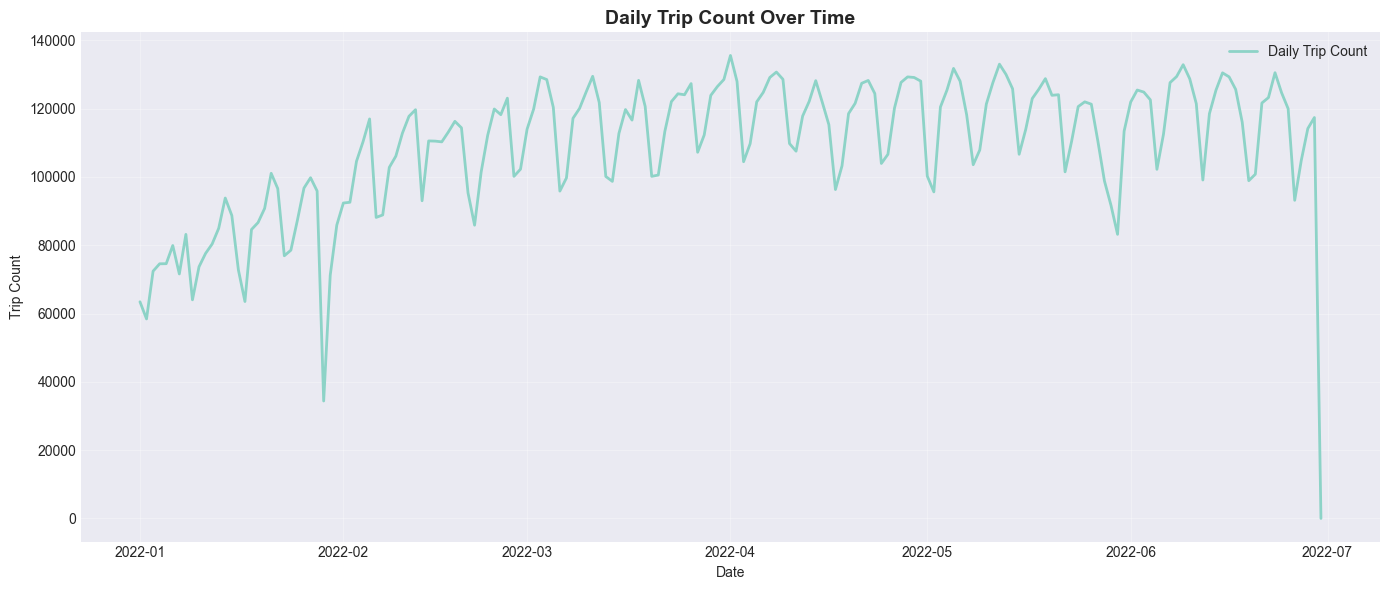

Observation: Clear weekly seasonality visible in the time series.
Higher counts mid-week, lower counts on weekends.


In [4]:
# Time series visualization
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(daily['date'], daily['daily_trip_count'], linewidth=2, label='Daily Trip Count')
ax.set_title('Daily Trip Count Over Time', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Trip Count')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

print("Observation: Clear weekly seasonality visible in the time series.")
print("Higher counts mid-week, lower counts on weekends.")

## Key Pattern: Weekly Seasonality

The time series shows a **strong 7-day repeating pattern**. This suggests:
- More taxi trips mid-week (higher demand)
- Fewer trips on weekends (lower demand)
- This seasonality is critical for feature engineering

Trip counts by day of week:
                    mean           std    min     max
weekday                                              
Monday      97985.115385  14596.155813  63518  118511
Tuesday    110701.692308  15200.213914  74562  127606
Wednesday  114878.153846  15726.811724  74592  130473
Thursday   114478.884615  27803.926903      1  133017
Friday     119077.120000  14785.220916  71590  135560
Saturday   111603.461538  22321.604178  34388  128585
Sunday      93647.615385  13686.975292  58421  109767


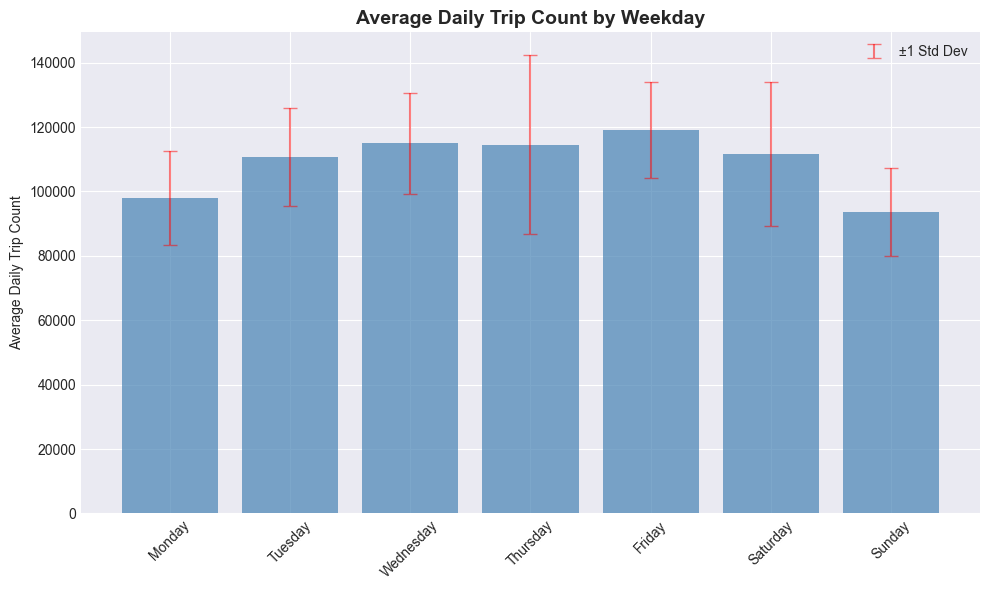

In [5]:
# Weekday analysis
daily['weekday'] = daily['date'].dt.day_name()
weekday_stats = daily.groupby('weekday')['daily_trip_count'].agg(['mean', 'std', 'min', 'max'])

# Reorder by day of week (0=Monday)
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_stats = weekday_stats.reindex(weekday_order)

print("Trip counts by day of week:")
print(weekday_stats)

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(range(len(weekday_stats)), weekday_stats['mean'], color='steelblue', alpha=0.7)
ax.errorbar(range(len(weekday_stats)), weekday_stats['mean'], yerr=weekday_stats['std'], 
            fmt='none', ecolor='red', alpha=0.5, capsize=5, label='±1 Std Dev')
ax.set_xticks(range(len(weekday_stats)))
ax.set_xticklabels(weekday_stats.index, rotation=45)
ax.set_ylabel('Average Daily Trip Count')
ax.set_title('Average Daily Trip Count by Weekday', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

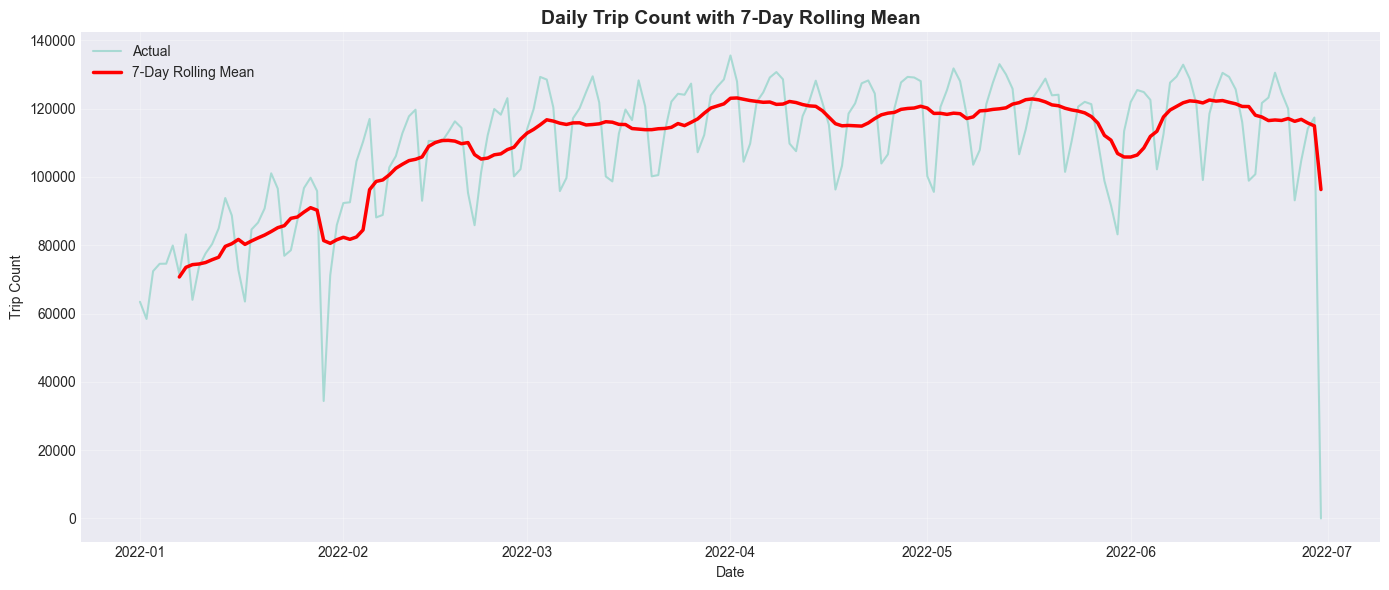

Interpretation: The 7-day rolling mean reveals the underlying trend,
filtering out the weekly fluctuations.
This suggests that a 7-day lag feature will be valuable for forecasting.


In [6]:
# 7-day rolling mean to smooth out weekly patterns
daily['rolling_mean_7'] = daily['daily_trip_count'].rolling(window=7, center=False).mean()

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(daily['date'], daily['daily_trip_count'], label='Actual', linewidth=1.5, alpha=0.7)
ax.plot(daily['date'], daily['rolling_mean_7'], label='7-Day Rolling Mean', linewidth=2.5, color='red')
ax.set_title('Daily Trip Count with 7-Day Rolling Mean', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Trip Count')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Interpretation: The 7-day rolling mean reveals the underlying trend,")
print("filtering out the weekly fluctuations.")
print("This suggests that a 7-day lag feature will be valuable for forecasting.")

## Feature Engineering Hypotheses

Based on the EDA, we should engineer features that capture:

1. **Trend**: Recent trajectory of trip counts → Use 7-day rolling window
2. **Seasonality**: The 7-day repeating pattern → Use lag_7 (same weekday last week)
3. **Day-to-day momentum**: Yesterday's count → Use lag_1
4. **Volatility**: Day-to-day variability → Use rolling std
5. **Calendar effects**: Which day of week/month → Use one-hot or numeric features
6. **Decomposed signal**: STL decomposition to extract trend and seasonal components

**Next step**: Build these features in notebook 02 and train a forecasting model.

In [7]:
print("\nEDA Complete")
print(f"Dataset: {len(daily)} days from {daily['date'].min().date()} to {daily['date'].max().date()}")


EDA Complete
Dataset: 181 days from 2022-01-01 to 2022-06-30
